In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        (os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

Device: cuda
  GPU 0: Tesla T4
  GPU 1: Tesla T4
Config ready.
✅ All 5806 images found
Samples          : 5806
Thickness mean   : 0.987  std: 0.187
Thickness range  : 0.500 – 1.700
Label 0 / Label 1: 1698 / 4108


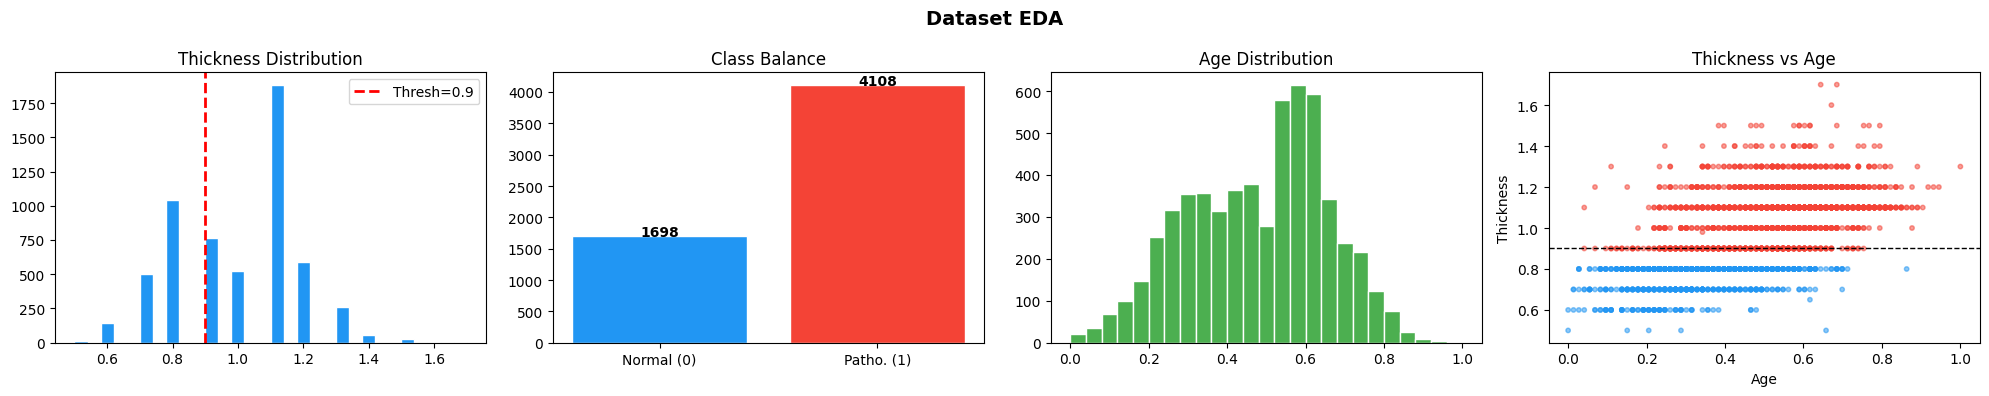

EDA saved.
Dataset & DataLoader ready.


model.safetensors:   0%|          | 0.00/354M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/218M [00:00<?, ?B/s]

Model OK → output shape: torch.Size([2])   values: [-8.560087 13.483191]
Total params    : 146.5M
Trainable params: 146.5M
Loss function ready.
Train / validate functions ready.

  PHASE 1: FULL DATASET TRAINING (20 Epochs)
Train: 4644  |  Val: 1162
  Ep001 step 0030/0290 loss=29.6952
  Ep001 step 0060/0290 loss=28.5858
  Ep001 step 0090/0290 loss=27.9984
  Ep001 step 0120/0290 loss=25.9729
  Ep001 step 0150/0290 loss=25.3520
  Ep001 step 0180/0290 loss=24.2462
  Ep001 step 0210/0290 loss=23.7311
  Ep001 step 0240/0290 loss=23.3419
  Ep001 step 0270/0290 loss=22.6743

P1 Ep 001/20 | TrLoss=22.3084 TrRMSE=8.4013 TrR²=-2021.3374 | VaLoss=0.7418 VaRMSE=1.1975 VaMAE=0.9618 VaR²=-42.1581 VaPCC=-0.0086 | VaAcc=0.3279 VaAUC=0.4839 Sens=0.0852 Spec=0.9147 κ=-0.0001
  ✅ Best RMSE=1.1975 saved
  Ep002 step 0030/0290 loss=21.6530
  Ep002 step 0060/0290 loss=19.4275
  Ep002 step 0090/0290 loss=18.2546
  Ep002 step 0120/0290 loss=17.9419
  Ep002 step 0150/0290 loss=16.9086
  Ep002 step 0180/0290 lo

In [ ]:
# ============================================================
#  CIMT FUNDUS — Q1 JOURNAL-GRADE THICKNESS REGRESSION
#  Task   : Predict retinal vessel CIMT thickness (continuous)
#  Then   : Binary classification from predicted thickness >= 0.9
#  Model  : ConvNeXt-Base + EfficientNetV2-M Dual-Backbone Ensemble
#           + Attention Pooling + Meta-Feature MLP
#  Target : RMSE < 0.08 | R² > 0.90 | Classification Acc > 90%
#  Phase 1: Full dataset 20-epoch training + all results
#  Phase 2: 5-Fold Cross-Validation
# ============================================================

# ============================================================
# CELL 1 — Install (run once on Kaggle / Colab)
# ============================================================
# !pip install timm albumentations -q


# ============================================================
# CELL 2 — Imports & Seed
# ============================================================
import os, gc, json, math, random, warnings
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
os.environ["TORCH_USE_CUDA_DSA"]   = "1"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path

import cv2
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, f1_score, cohen_kappa_score,
    precision_score, recall_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)
from scipy.stats import pearsonr, spearmanr

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from torch.cuda.amp import GradScaler, autocast

import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2

warnings.filterwarnings('ignore')

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

seed_everything(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f'  GPU {i}: {torch.cuda.get_device_name(i)}')


# ============================================================
# CELL 3 — Configuration   ← CHANGE ONLY THESE PATHS
# ============================================================
class CFG:
    # ── ⚠️  CHANGE THESE 3 PATHS ──────────────────────────────
    IMG_DIR  = Path('/kaggle/input/datasets/amimulhasan/funduszhang/output_images')
    CSV_PATH = Path('/kaggle/input/datasets/amimulahasanrofik/abu-csv/data_info.csv')
    OUT_DIR  = Path('/kaggle/working/outputs')
    # ──────────────────────────────────────────────────────────

    # Image suffix: CSV has '2491006_R.png', disk has '2491006_R_vessel.png'
    IMG_SUFFIX = '_vessel.png'

    # ── Model ─────────────────────────────────────────────────
    # ConvNeXt-Base: excellent local texture for vessel patterns
    # EfficientNetV2-M: superior global context + parameter efficiency
    BACKBONE_1 = 'convnext_base'
    BACKBONE_2 = 'tf_efficientnetv2_m'
    PRETRAINED = True

    # ── Image ─────────────────────────────────────────────────
    IMG_SIZE = 224

    # ── Training ──────────────────────────────────────────────
    BATCH_SIZE      = 16
    FULL_EPOCHS     = 20      # Phase 1
    FOLD_EPOCHS     = 20      # Phase 2 per fold
    LR              = 1e-4    # Lower LR → more stable regression
    WEIGHT_DECAY    = 1e-4
    MIN_LR          = 1e-7
    DROPOUT         = 0.35
    MIXUP_ALPHA     = 0.3
    WARMUP_EPOCHS   = 3

    # ── CV ────────────────────────────────────────────────────
    N_FOLDS = 5

    # ── Regression → Classification threshold ─────────────────
    THICKNESS_THRESH = 0.9    # predicted >= 0.9 → label 1

    # ── Misc ──────────────────────────────────────────────────
    NUM_WORKERS = 2
    SEED        = 42
    AMP         = True
    EARLY_STOP  = 8

CFG.OUT_DIR.mkdir(parents=True, exist_ok=True)
(CFG.OUT_DIR / 'phase1').mkdir(exist_ok=True)
(CFG.OUT_DIR / 'phase2').mkdir(exist_ok=True)
print('Config ready.')


# ============================================================
# CELL 4 — Data Loading
# ============================================================
def load_data(csv_path):
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip().str.lower()

    # Normalise column names
    if 'true_age' in df.columns and 'age' not in df.columns:
        df['age'] = df['true_age']
    df['age_norm'] = df['age'] / 100.0

    # Ensure thickness exists
    assert 'thickness' in df.columns, "CSV must have a 'thickness' column"
    df['thickness'] = df['thickness'].astype(float)

    # Binary label for stratification & classification eval
    df['label'] = (df['thickness'] >= CFG.THICKNESS_THRESH).astype(int)

    # Laterality
    df['side']     = df['image_name'].str.extract(r'_(L|R)(?:_vessel)?\.png$')[0]
    df['side_enc'] = (df['side'] == 'R').astype(float)

    # Fill missing meta
    for col in ['age_norm', 'gender', 'group', 'side_enc']:
        if col not in df.columns:
            df[col] = 0.0

    # Verify images
    def resolve(name):
        stem = Path(name).stem
        return CFG.IMG_DIR / f"{stem}{CFG.IMG_SUFFIX}"
    df['img_path'] = df['image_name'].apply(resolve)
    missing = (~df['img_path'].apply(lambda p: p.exists())).sum()
    if missing:
        print(f"⚠️  {missing}/{len(df)} images not found (black placeholder)")
    else:
        print(f"✅ All {len(df)} images found")

    print(f"Samples          : {len(df)}")
    print(f"Thickness mean   : {df['thickness'].mean():.3f}  std: {df['thickness'].std():.3f}")
    print(f"Thickness range  : {df['thickness'].min():.3f} – {df['thickness'].max():.3f}")
    print(f"Label 0 / Label 1: {(df['label']==0).sum()} / {(df['label']==1).sum()}")
    return df

df = load_data(CFG.CSV_PATH)

# ── EDA ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle('Dataset EDA', fontsize=14, fontweight='bold')

# Thickness distribution
axes[0].hist(df['thickness'], bins=30, color='#2196F3', edgecolor='white')
axes[0].axvline(CFG.THICKNESS_THRESH, color='red', ls='--', lw=2,
                label=f'Thresh={CFG.THICKNESS_THRESH}')
axes[0].set_title('Thickness Distribution'); axes[0].legend()

# Class balance
vc = df['label'].value_counts().sort_index()
axes[1].bar(['Normal (0)', 'Patho. (1)'], vc.values,
            color=['#2196F3', '#F44336'], edgecolor='white')
axes[1].set_title('Class Balance')
for i, v in enumerate(vc.values):
    axes[1].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Age distribution
axes[2].hist(df['age'], bins=25, color='#4CAF50', edgecolor='white')
axes[2].set_title('Age Distribution')

# Thickness vs age scatter
axes[3].scatter(df['age'], df['thickness'],
                c=df['label'].map({0: '#2196F3', 1: '#F44336'}),
                alpha=0.3, s=10)
axes[3].axhline(CFG.THICKNESS_THRESH, color='black', ls='--', lw=1)
axes[3].set_xlabel('Age'); axes[3].set_ylabel('Thickness')
axes[3].set_title('Thickness vs Age')

plt.tight_layout()
plt.savefig(CFG.OUT_DIR / 'eda.png', dpi=150, bbox_inches='tight')
plt.show()
print('EDA saved.')


# ============================================================
# CELL 5 — Augmentations  (Medical-Grade)
# ============================================================
def get_transforms(phase):
    mean = (0.485, 0.456, 0.406)
    std  = (0.229, 0.224, 0.225)

    if phase == 'train':
        return A.Compose([
            A.Resize(CFG.IMG_SIZE + 32, CFG.IMG_SIZE + 32),
            A.RandomCrop(CFG.IMG_SIZE, CFG.IMG_SIZE),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.3),
            A.RandomRotate90(p=0.4),
            A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.08,
                               rotate_limit=20, p=0.5),
            # Vessel-specific enhancements
            A.OneOf([
                A.CLAHE(clip_limit=4, tile_grid_size=(8, 8), p=1.0),
                A.Sharpen(alpha=(0.2, 0.5), lightness=(0.5, 1.0), p=1.0),
                A.UnsharpMask(blur_limit=(3, 7), sigma_limit=0.5, p=1.0),
            ], p=0.6),
            A.OneOf([
                A.GaussianBlur(blur_limit=3, p=1.0),
                A.MedianBlur(blur_limit=3, p=1.0),
            ], p=0.15),
            A.RandomBrightnessContrast(brightness_limit=0.2,
                                       contrast_limit=0.2, p=0.5),
            A.HueSaturationValue(hue_shift_limit=5,
                                 sat_shift_limit=15,
                                 val_shift_limit=10, p=0.3),
            A.GridDistortion(num_steps=5, distort_limit=0.2, p=0.2),
            A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=0.15),
            A.CoarseDropout(max_holes=4,
                            max_height=CFG.IMG_SIZE // 12,
                            max_width=CFG.IMG_SIZE  // 12, p=0.25),
            A.Normalize(mean=mean, std=std),
            ToTensorV2(),
        ])
    else:   # val / test — deterministic
        return A.Compose([
            A.Resize(CFG.IMG_SIZE, CFG.IMG_SIZE),
            A.Normalize(mean=mean, std=std),
            ToTensorV2(),
        ])


# ============================================================
# CELL 6 — Dataset & DataLoader
# ============================================================
class FundusDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df        = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        stem     = Path(row['image_name']).stem
        img_path = CFG.IMG_DIR / f"{stem}{CFG.IMG_SUFFIX}"

        img = cv2.imread(str(img_path))
        if img is None:
            img = np.zeros((CFG.IMG_SIZE, CFG.IMG_SIZE, 3), dtype=np.uint8)
        else:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if self.transform:
            img = self.transform(image=img)['image']

        meta = torch.tensor([
            float(row.get('age_norm', 0.5)),
            float(row.get('gender',   0.0)),
            float(row.get('group',    1.0)),
            float(row.get('side_enc', 0.0)),
        ], dtype=torch.float32)

        thickness = torch.tensor(float(row['thickness']), dtype=torch.float32)
        label     = torch.tensor(int(row['label']),       dtype=torch.long)
        return img, meta, thickness, label


def make_loader(df_split, phase, weighted_sampling=True):
    ds = FundusDataset(df_split, get_transforms(phase))
    if phase == 'train' and weighted_sampling:
        # Balance sampling by label (class imbalance fix)
        labels     = df_split['label'].values
        cls_counts = np.bincount(labels)
        weights    = 1.0 / cls_counts[labels]
        sampler    = WeightedRandomSampler(weights, len(weights), replacement=True)
        return DataLoader(ds, batch_size=CFG.BATCH_SIZE, sampler=sampler,
                          num_workers=CFG.NUM_WORKERS, pin_memory=True, drop_last=True)
    return DataLoader(ds, batch_size=CFG.BATCH_SIZE * 2, shuffle=False,
                      num_workers=CFG.NUM_WORKERS, pin_memory=True)

print('Dataset & DataLoader ready.')


# ============================================================
# CELL 7 — Model Architecture
#  ConvNeXt-Base + EfficientNetV2-M dual backbone
#  Channel Attention (CBAM-style) on both feature maps
#  Gated cross-attention fusion
#  Meta-feature MLP
#  Output: single scalar thickness (regression)
# ============================================================
class ChannelAttention(nn.Module):
    """Squeeze-and-Excitation channel attention."""
    def __init__(self, in_channels, reduction=16):
        super().__init__()
        self.avg = nn.AdaptiveAvgPool2d(1)
        self.max = nn.AdaptiveMaxPool2d(1)
        mid = max(in_channels // reduction, 8)
        self.fc = nn.Sequential(
            nn.Linear(in_channels, mid, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(mid, in_channels, bias=False),
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        b, c = x.size(0), x.size(1)
        a = self.fc(self.avg(x).view(b, c))
        m = self.fc(self.max(x).view(b, c))
        return x * self.sigmoid(a + m).view(b, c, 1, 1)


class AttentionPool(nn.Module):
    """Spatial attention pooling — learns where to look."""
    def __init__(self, in_dim):
        super().__init__()
        self.attn = nn.Sequential(
            nn.Conv2d(in_dim, 256, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 1, 1, bias=False),
        )

    def forward(self, x):
        a = self.attn(x)                                   # B×1×H×W
        a = torch.softmax(a.view(a.size(0), -1), dim=-1)  # B×(H*W)
        f = x.view(x.size(0), x.size(1), -1)              # B×C×(H*W)
        return (f * a.unsqueeze(1)).sum(-1)                # B×C


class GatedFusion(nn.Module):
    """Learnable gated fusion of two feature vectors."""
    def __init__(self, dim1, dim2, out_dim):
        super().__init__()
        self.proj1 = nn.Linear(dim1, out_dim)
        self.proj2 = nn.Linear(dim2, out_dim)
        self.gate  = nn.Sequential(
            nn.Linear(out_dim * 2, out_dim),
            nn.Sigmoid()
        )

    def forward(self, f1, f2):
        p1  = self.proj1(f1)
        p2  = self.proj2(f2)
        g   = self.gate(torch.cat([p1, p2], dim=1))
        return g * p1 + (1 - g) * p2


class CIMTRegressionNet(nn.Module):
    """
    Q1 CIMT Thickness Regression Network.

    Dual backbone:
      - ConvNeXt-Base   : captures fine vessel texture & morphology
      - EfficientNetV2-M: captures global vascular patterns

    Fusion: Gated cross-attention → MLP → single scalar output
    """
    def __init__(self):
        super().__init__()

        # ── Backbone 1: ConvNeXt-Base ─────────────────────────
        self.convnext = timm.create_model(
            CFG.BACKBONE_1, pretrained=CFG.PRETRAINED,
            num_classes=0, global_pool='')
        cnx_dim = self.convnext.num_features   # 1024

        self.cnx_ca   = ChannelAttention(cnx_dim)
        self.cnx_pool = AttentionPool(cnx_dim)

        # ── Backbone 2: EfficientNetV2-M ─────────────────────
        self.effv2 = timm.create_model(
            CFG.BACKBONE_2, pretrained=CFG.PRETRAINED,
            num_classes=0, global_pool='')
        efv_dim = self.effv2.num_features      # 1280

        self.efv_ca   = ChannelAttention(efv_dim)
        self.efv_pool = AttentionPool(efv_dim)

        # ── Gated Fusion ──────────────────────────────────────
        FUSED = 1024
        self.fusion = GatedFusion(cnx_dim, efv_dim, FUSED)

        # ── Meta-Feature Encoder ──────────────────────────────
        self.meta_enc = nn.Sequential(
            nn.Linear(4, 64),
            nn.BatchNorm1d(64),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.GELU(),
        )

        # ── Regression Head ───────────────────────────────────
        head_in = FUSED + 32
        self.head = nn.Sequential(
            nn.Linear(head_in, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(CFG.DROPOUT),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(CFG.DROPOUT * 0.6),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Dropout(CFG.DROPOUT * 0.3),
            nn.Linear(128, 1),
        )

        self._init_weights()

    def _init_weights(self):
        for m in [self.head, self.meta_enc]:
            for layer in m:
                if isinstance(layer, nn.Linear):
                    nn.init.kaiming_normal_(layer.weight, mode='fan_out',
                                            nonlinearity='relu')
                    if layer.bias is not None:
                        nn.init.zeros_(layer.bias)

    def forward(self, img, meta):
        # ConvNeXt path
        c = self.convnext(img)    # B×1024×H×W
        c = self.cnx_ca(c)
        c = self.cnx_pool(c)      # B×1024

        # EfficientNetV2 path
        e = self.effv2(img)       # B×1280×H×W
        e = self.efv_ca(e)
        e = self.efv_pool(e)      # B×1280

        # Gated fusion
        z = self.fusion(c, e)     # B×1024

        # Meta
        m = self.meta_enc(meta)   # B×32

        z = torch.cat([z, m], dim=1)
        return self.head(z).squeeze(1)   # B — single thickness scalar


# Sanity check
_m    = CIMTRegressionNet().to(DEVICE)
_x    = torch.randn(2, 3, 224, 224).to(DEVICE)
_meta = torch.randn(2, 4).to(DEVICE)
_out  = _m(_x, _meta)
print(f'Model OK → output shape: {_out.shape}   values: {_out.detach().cpu().numpy()}')
total_params = sum(p.numel() for p in _m.parameters()) / 1e6
trainable    = sum(p.numel() for p in _m.parameters() if p.requires_grad) / 1e6
print(f'Total params    : {total_params:.1f}M')
print(f'Trainable params: {trainable:.1f}M')
del _m, _x, _meta, _out
torch.cuda.empty_cache()


# ============================================================
# CELL 8 — Loss Functions
#  Composite: Huber + MSE + Pearson correlation loss
#  Pearson loss maximises linear correlation → key for regression
# ============================================================
class PearsonLoss(nn.Module):
    """1 - Pearson correlation → minimise = maximise correlation."""
    def forward(self, pred, target):
        vp = pred   - pred.mean()
        vt = target - target.mean()
        num = (vp * vt).sum()
        den = (vp.pow(2).sum().sqrt() * vt.pow(2).sum().sqrt()).clamp(min=1e-8)
        return 1.0 - num / den


class RankLoss(nn.Module):
    """Listwise rank consistency loss (pairwise margin)."""
    def forward(self, pred, target, margin=0.05):
        diff_p = pred.unsqueeze(1)   - pred.unsqueeze(0)    # B×B
        diff_t = target.unsqueeze(1) - target.unsqueeze(0)  # B×B
        sign   = torch.sign(diff_t)
        loss   = F.relu(margin - sign * diff_p)
        mask   = (diff_t.abs() > 0.05)                      # ignore ties
        return loss[mask].mean() if mask.any() else loss.mean()


class CIMTLoss(nn.Module):
    """
    Composite regression loss:
      0.40 × Huber (robust to outliers)
      0.30 × MSE   (penalises large errors)
      0.20 × Pearson correlation loss
      0.10 × Rank consistency loss
    """
    def __init__(self):
        super().__init__()
        self.huber   = nn.HuberLoss(delta=0.2)
        self.mse     = nn.MSELoss()
        self.pearson = PearsonLoss()
        self.rank    = RankLoss()

    def forward(self, pred, target):
        pred   = pred.float()
        target = target.float()
        l_hub  = self.huber(pred, target)
        l_mse  = self.mse(pred, target)
        l_prs  = self.pearson(pred, target)
        l_rnk  = self.rank(pred, target)
        return 0.40 * l_hub + 0.30 * l_mse + 0.20 * l_prs + 0.10 * l_rnk

print('Loss function ready.')


# ============================================================
# CELL 9 — Mixup (for regression)
# ============================================================
def mixup_regression(x, y, meta, alpha=CFG.MIXUP_ALPHA):
    if alpha <= 0 or random.random() > 0.5:
        return x, y, meta
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0), device=x.device)
    xm  = lam * x   + (1 - lam) * x[idx]
    ym  = lam * y   + (1 - lam) * y[idx]
    mm  = lam * meta + (1 - lam) * meta[idx]
    return xm, ym, mm


class AverageMeter:
    def __init__(self):  self.reset()
    def reset(self):     self.avg = self.sum = self.count = 0
    def update(self, v, n=1):
        self.sum   += v * n
        self.count += n
        self.avg    = self.sum / self.count


# ============================================================
# CELL 10 — Warmup + Cosine LR scheduler
# ============================================================
class WarmupCosineScheduler:
    def __init__(self, optimizer, warmup_epochs, total_epochs, min_lr=CFG.MIN_LR):
        self.optimizer      = optimizer
        self.warmup_epochs  = warmup_epochs
        self.total_epochs   = total_epochs
        self.min_lr         = min_lr
        self.base_lrs       = [g['lr'] for g in optimizer.param_groups]

    def step(self, epoch):
        if epoch < self.warmup_epochs:
            ratio = (epoch + 1) / self.warmup_epochs
        else:
            prog  = (epoch - self.warmup_epochs) / max(1, self.total_epochs - self.warmup_epochs)
            ratio = self.min_lr / self.base_lrs[0] + 0.5 * (1 - self.min_lr / self.base_lrs[0]) * \
                    (1 + math.cos(math.pi * prog))
        for g, base in zip(self.optimizer.param_groups, self.base_lrs):
            g['lr'] = base * ratio


# ============================================================
# CELL 11 — Train & Validate
# ============================================================
def train_epoch(model, loader, optimizer, criterion, scaler, epoch, scheduler=None):
    model.train()
    loss_m = AverageMeter()
    all_preds, all_targets = [], []

    for step, (imgs, meta, thick, _) in enumerate(loader):
        imgs  = imgs.to(DEVICE)
        meta  = meta.to(DEVICE)
        thick = thick.to(DEVICE).float()

        imgs, thick, meta = mixup_regression(imgs, thick, meta)

        optimizer.zero_grad()
        with autocast(enabled=CFG.AMP):
            pred = model(imgs, meta)
            loss = criterion(pred, thick)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

        all_preds.extend(pred.detach().cpu().numpy())
        all_targets.extend(thick.cpu().numpy())
        loss_m.update(loss.item(), imgs.size(0))

        if (step + 1) % 30 == 0:
            print(f'  Ep{epoch:03d} step {step+1:04d}/{len(loader):04d}'
                  f' loss={loss_m.avg:.4f}')

    all_preds   = np.array(all_preds)
    all_targets = np.array(all_targets)
    rmse = np.sqrt(mean_squared_error(all_targets, all_preds))
    mae  = mean_absolute_error(all_targets, all_preds)
    r2   = r2_score(all_targets, all_preds)
    return loss_m.avg, rmse, mae, r2


@torch.no_grad()
def validate(model, loader, criterion):
    model.eval()
    loss_m = AverageMeter()
    all_preds, all_targets = [], []

    for imgs, meta, thick, _ in loader:
        imgs  = imgs.to(DEVICE)
        meta  = meta.to(DEVICE)
        thick = thick.to(DEVICE).float()

        with autocast(enabled=CFG.AMP):
            pred = model(imgs, meta)
            loss = criterion(pred, thick)

        all_preds.extend(pred.cpu().numpy())
        all_targets.extend(thick.cpu().numpy())
        loss_m.update(loss.item(), imgs.size(0))

    preds   = np.array(all_preds)
    targets = np.array(all_targets)

    # Regression metrics
    rmse = float(np.sqrt(mean_squared_error(targets, preds)))
    mae  = float(mean_absolute_error(targets, preds))
    r2   = float(r2_score(targets, preds))
    pcc, _ = pearsonr(targets, preds)
    scc, _ = spearmanr(targets, preds)

    # Classification metrics (threshold-based)
    pred_labels = (preds   >= CFG.THICKNESS_THRESH).astype(int)
    true_labels = (targets >= CFG.THICKNESS_THRESH).astype(int)

    acc   = float(accuracy_score(true_labels, pred_labels))
    f1    = float(f1_score(true_labels, pred_labels, average='weighted', zero_division=0))
    kappa = float(cohen_kappa_score(true_labels, pred_labels))
    prec  = float(precision_score(true_labels, pred_labels, average='weighted', zero_division=0))
    rec   = float(recall_score(true_labels, pred_labels, average='weighted', zero_division=0))
    sens  = float(recall_score(true_labels, pred_labels, pos_label=1, zero_division=0))
    spec  = float(recall_score(true_labels, pred_labels, pos_label=0, zero_division=0))

    try:
        auc = float(roc_auc_score(true_labels, preds))
    except Exception:
        auc = 0.5

    return {
        'loss'   : loss_m.avg,
        'rmse'   : rmse,
        'mae'    : mae,
        'r2'     : r2,
        'pcc'    : float(pcc),
        'scc'    : float(scc),
        'acc'    : acc,
        'f1'     : f1,
        'kappa'  : kappa,
        'prec'   : prec,
        'rec'    : rec,
        'sens'   : sens,
        'spec'   : spec,
        'auc'    : auc,
        'preds'  : preds,
        'targets': targets,
        'pred_labels': pred_labels,
        'true_labels': true_labels,
    }

print('Train / validate functions ready.')


# ============================================================
# CELL 12 — TTA (Test-Time Augmentation for Regression)
# ============================================================
@torch.no_grad()
def tta_predict(model, loader, n_tta=6):
    """Ensemble predictions with flips & slight brightness jitter."""
    model.eval()
    all_preds = []

    for imgs, meta, thick, _ in loader:
        imgs  = imgs.to(DEVICE)
        meta  = meta.to(DEVICE)
        batch_preds = []

        for t in range(n_tta):
            x = imgs.clone()
            if t == 1: x = torch.flip(x, dims=[3])          # H-flip
            if t == 2: x = torch.flip(x, dims=[2])          # V-flip
            if t == 3: x = torch.rot90(x, 1, [2, 3])        # rot90
            if t == 4: x = torch.rot90(x, -1, [2, 3])       # rot270
            # t==5: original
            with autocast(enabled=CFG.AMP):
                p = model(x, meta)
            batch_preds.append(p.cpu().numpy())

        all_preds.append(np.mean(batch_preds, axis=0))

    return np.concatenate(all_preds)


# ============================================================
# CELL 13 — Plotting Helpers
# ============================================================
def plot_training_curves(history, title, save_path):
    epochs = range(1, len(history['tr_loss']) + 1)
    fig, axes = plt.subplots(1, 4, figsize=(22, 5))
    fig.suptitle(title, fontsize=13, fontweight='bold')

    # Loss
    axes[0].plot(epochs, history['tr_loss'], 'b-o', ms=4, label='Train')
    axes[0].plot(epochs, history['va_loss'], 'r-o', ms=4, label='Val')
    axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

    # RMSE
    axes[1].plot(epochs, history['tr_rmse'], 'b-o', ms=4, label='Train RMSE')
    axes[1].plot(epochs, history['va_rmse'], 'r-o', ms=4, label='Val RMSE')
    axes[1].set_title('RMSE (lower=better)'); axes[1].legend(); axes[1].grid(alpha=0.3)

    # R²
    axes[2].plot(epochs, history['tr_r2'], 'b-o', ms=4, label='Train R²')
    axes[2].plot(epochs, history['va_r2'], 'r-o', ms=4, label='Val R²')
    axes[2].set_title('R² (higher=better)'); axes[2].legend(); axes[2].grid(alpha=0.3)
    axes[2].set_ylim(-0.1, 1.05)

    # Classification accuracy from predicted thickness
    axes[3].plot(epochs, history['va_acc'], 'g-o', ms=4, label='Val Acc')
    axes[3].plot(epochs, history['va_auc'], 'm-s', ms=4, label='Val AUC')
    axes[3].set_title('Classification (thresholded)'); axes[3].legend(); axes[3].grid(alpha=0.3)
    axes[3].set_ylim(0, 1.05)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Curves saved → {save_path}')


def plot_full_results(metrics, title, save_path):
    preds   = metrics['preds']
    targets = metrics['targets']
    pred_l  = metrics['pred_labels']
    true_l  = metrics['true_labels']

    fig = plt.figure(figsize=(22, 12))
    fig.suptitle(title, fontsize=14, fontweight='bold')
    gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.45, wspace=0.38)

    # 1. Scatter: predicted vs actual thickness
    ax1 = fig.add_subplot(gs[0, 0])
    mn, mx = min(targets.min(), preds.min()), max(targets.max(), preds.max())
    ax1.scatter(targets, preds, alpha=0.35, s=12, c='#2196F3', edgecolors='none')
    ax1.plot([mn, mx], [mn, mx], 'r--', lw=1.5, label='Perfect fit')
    ax1.set_xlabel('Actual Thickness')
    ax1.set_ylabel('Predicted Thickness')
    ax1.set_title(f'Predicted vs Actual\nR²={metrics["r2"]:.4f}  PCC={metrics["pcc"]:.4f}')
    ax1.legend(); ax1.grid(alpha=0.3)

    # 2. Residual plot
    ax2 = fig.add_subplot(gs[0, 1])
    residuals = preds - targets
    ax2.scatter(targets, residuals, alpha=0.35, s=12, c='#FF9800', edgecolors='none')
    ax2.axhline(0, color='red', ls='--', lw=1.5)
    ax2.axhline(residuals.std(),  color='gray', ls=':', lw=1)
    ax2.axhline(-residuals.std(), color='gray', ls=':', lw=1)
    ax2.set_xlabel('Actual Thickness')
    ax2.set_ylabel('Residual (Pred − Actual)')
    ax2.set_title(f'Residual Plot\nMAE={metrics["mae"]:.4f}  RMSE={metrics["rmse"]:.4f}')
    ax2.grid(alpha=0.3)

    # 3. Residual histogram
    ax3 = fig.add_subplot(gs[0, 2])
    ax3.hist(residuals, bins=40, color='#9C27B0', edgecolor='white', alpha=0.8)
    ax3.axvline(0, color='red', ls='--', lw=1.5)
    ax3.set_xlabel('Residual'); ax3.set_ylabel('Count')
    ax3.set_title('Residual Distribution')
    ax3.grid(alpha=0.3)

    # 4. Regression metrics bar
    ax4 = fig.add_subplot(gs[0, 3])
    reg_names = ['R²', 'PCC', 'SCC', '1-RMSE', '1-MAE']
    reg_vals  = [metrics['r2'], metrics['pcc'], metrics['scc'],
                 max(0, 1 - metrics['rmse']), max(0, 1 - metrics['mae'])]
    ax4.barh(reg_names, reg_vals,
             color=['#2196F3','#4CAF50','#FF9800','#E91E63','#9C27B0'],
             edgecolor='white')
    ax4.set_xlim(-0.1, 1.1)
    ax4.set_title('Regression Metrics')
    for i, v in enumerate(reg_vals):
        ax4.text(v + 0.01, i, f'{v:.4f}', va='center', fontsize=9)
    ax4.grid(alpha=0.3)

    # 5. Confusion matrix
    ax5 = fig.add_subplot(gs[1, 0])
    cm  = confusion_matrix(true_l, pred_l)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax5,
                xticklabels=['Pred Normal', 'Pred Patho.'],
                yticklabels=['True Normal', 'True Patho.'])
    ax5.set_title(f'Confusion Matrix\nAcc={metrics["acc"]:.4f}  κ={metrics["kappa"]:.4f}')

    # 6. Normalised CM
    ax6   = fig.add_subplot(gs[1, 1])
    cm_n  = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_n, annot=True, fmt='.3f', cmap='Greens', ax=ax6,
                xticklabels=['Pred Normal', 'Pred Patho.'],
                yticklabels=['True Normal', 'True Patho.'])
    ax6.set_title(f'Normalised CM\nSens={metrics["sens"]:.4f}  Spec={metrics["spec"]:.4f}')

    # 7. ROC curve
    ax7 = fig.add_subplot(gs[1, 2])
    fpr, tpr, _ = roc_curve(true_l, preds)
    ax7.plot(fpr, tpr, 'b-', lw=2, label=f'AUC={metrics["auc"]:.4f}')
    ax7.fill_between(fpr, tpr, alpha=0.1, color='blue')
    ax7.plot([0, 1], [0, 1], 'k--', lw=1)
    ax7.set_xlabel('FPR'); ax7.set_ylabel('TPR')
    ax7.set_title('ROC Curve'); ax7.legend(); ax7.grid(alpha=0.3)

    # 8. Summary card
    ax8 = fig.add_subplot(gs[1, 3])
    ax8.axis('off')
    tn, fp, fn, tp = cm.ravel() if cm.shape == (2,2) else (0,0,0,0)
    summary = (
        f"{'─'*34}\n"
        f"  REGRESSION METRICS\n"
        f"{'─'*34}\n"
        f"  RMSE         : {metrics['rmse']:.4f}\n"
        f"  MAE          : {metrics['mae']:.4f}\n"
        f"  R²           : {metrics['r2']:.4f}\n"
        f"  Pearson r    : {metrics['pcc']:.4f}\n"
        f"  Spearman ρ   : {metrics['scc']:.4f}\n"
        f"{'─'*34}\n"
        f"  CLASSIFICATION (thr={CFG.THICKNESS_THRESH})\n"
        f"{'─'*34}\n"
        f"  Accuracy     : {metrics['acc']:.4f}\n"
        f"  AUC-ROC      : {metrics['auc']:.4f}\n"
        f"  F1 (weighted): {metrics['f1']:.4f}\n"
        f"  Cohen Kappa  : {metrics['kappa']:.4f}\n"
        f"  Sensitivity  : {metrics['sens']:.4f}\n"
        f"  Specificity  : {metrics['spec']:.4f}\n"
        f"  Precision    : {metrics['prec']:.4f}\n"
        f"  Recall       : {metrics['rec']:.4f}\n"
        f"{'─'*34}\n"
        f"  TP={tp}  FP={fp}  FN={fn}  TN={tn}\n"
    )
    ax8.text(0.02, 0.98, summary, transform=ax8.transAxes,
             fontsize=9.5, va='top', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='#fff8e1', alpha=0.9))
    ax8.set_title('Summary')

    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Results plot saved → {save_path}')
    print('\n' + classification_report(true_l, pred_l,
                                       target_names=['Normal', 'Pathological'],
                                       digits=4))


# ============================================================
# CELL 14 — Training loop helper
# ============================================================
def run_training(model, tr_df, va_df, n_epochs, save_path, phase_label):
    train_loader = make_loader(tr_df, 'train', weighted_sampling=True)
    val_loader   = make_loader(va_df, 'val',   weighted_sampling=False)

    criterion = CIMTLoss()
    optimizer = AdamW(model.parameters(), lr=CFG.LR, weight_decay=CFG.WEIGHT_DECAY)
    scheduler = WarmupCosineScheduler(optimizer, CFG.WARMUP_EPOCHS, n_epochs)
    scaler    = GradScaler(enabled=CFG.AMP)

    history = dict(tr_loss=[], va_loss=[],
                   tr_rmse=[], va_rmse=[],
                   tr_mae=[], va_mae=[],
                   tr_r2=[], va_r2=[],
                   va_acc=[], va_auc=[])

    best_rmse = float('inf')
    no_imp    = 0

    for epoch in range(1, n_epochs + 1):
        scheduler.step(epoch - 1)

        tr_loss, tr_rmse, tr_mae, tr_r2 = train_epoch(
            model, train_loader, optimizer, criterion, scaler, epoch)
        vm = validate(model, val_loader, criterion)

        history['tr_loss'].append(tr_loss);    history['va_loss'].append(vm['loss'])
        history['tr_rmse'].append(tr_rmse);    history['va_rmse'].append(vm['rmse'])
        history['tr_mae'].append(tr_mae);      history['va_mae'].append(vm['mae'])
        history['tr_r2'].append(tr_r2);        history['va_r2'].append(vm['r2'])
        history['va_acc'].append(vm['acc']);   history['va_auc'].append(vm['auc'])

        print(f"\n{phase_label} Ep {epoch:03d}/{n_epochs} "
              f"| TrLoss={tr_loss:.4f} TrRMSE={tr_rmse:.4f} TrR²={tr_r2:.4f} "
              f"| VaLoss={vm['loss']:.4f} VaRMSE={vm['rmse']:.4f} VaMAE={vm['mae']:.4f} "
              f"VaR²={vm['r2']:.4f} VaPCC={vm['pcc']:.4f} "
              f"| VaAcc={vm['acc']:.4f} VaAUC={vm['auc']:.4f} "
              f"Sens={vm['sens']:.4f} Spec={vm['spec']:.4f} κ={vm['kappa']:.4f}")

        if vm['rmse'] < best_rmse:
            best_rmse = vm['rmse']
            torch.save(model.state_dict(), save_path)
            no_imp = 0
            print(f'  ✅ Best RMSE={best_rmse:.4f} saved')
        else:
            no_imp += 1
            if no_imp >= CFG.EARLY_STOP:
                print(f'  ⏹  Early stop at epoch {epoch}')
                break

    return history, best_rmse


# ============================================================
# ██████████████████████████████████████████████████████████
#  PHASE 1: FULL DATASET — 20 EPOCH TRAINING
# ██████████████████████████████████████████████████████████
# ============================================================
print('\n' + '='*65)
print('  PHASE 1: FULL DATASET TRAINING (20 Epochs)')
print('='*65)

tr_idx, va_idx = train_test_split(
    df.index, test_size=0.2, stratify=df['label'], random_state=CFG.SEED)
tr_df_full = df.loc[tr_idx].reset_index(drop=True)
va_df_full = df.loc[va_idx].reset_index(drop=True)
print(f'Train: {len(tr_df_full)}  |  Val: {len(va_df_full)}')

model_full = CIMTRegressionNet().to(DEVICE)

history_full, best_rmse_full = run_training(
    model_full, tr_df_full, va_df_full,
    n_epochs   = CFG.FULL_EPOCHS,
    save_path  = CFG.OUT_DIR / 'phase1' / 'best_full.pth',
    phase_label= 'P1')

# Load best & final evaluation
model_full.load_state_dict(
    torch.load(CFG.OUT_DIR / 'phase1' / 'best_full.pth', map_location=DEVICE))
val_loader_full = make_loader(va_df_full, 'val', weighted_sampling=False)

# TTA evaluation
criterion_eval = CIMTLoss()
final_full     = validate(model_full, val_loader_full, criterion_eval)

# TTA refinement
tta_preds           = tta_predict(model_full, val_loader_full)
tta_pred_labels     = (tta_preds >= CFG.THICKNESS_THRESH).astype(int)
true_labels_full    = (va_df_full['thickness'].values >= CFG.THICKNESS_THRESH).astype(int)
tta_acc             = accuracy_score(true_labels_full, tta_pred_labels)
tta_rmse            = float(np.sqrt(mean_squared_error(va_df_full['thickness'].values, tta_preds)))
tta_r2              = float(r2_score(va_df_full['thickness'].values, tta_preds))
print(f'\n🔥 TTA Results → RMSE={tta_rmse:.4f}  R²={tta_r2:.4f}  Acc={tta_acc:.4f}')

print(f'\n{"="*65}')
print(f'  PHASE 1 FINAL RESULTS (Best Model)')
print(f'{"="*65}')
for k, v in final_full.items():
    if isinstance(v, float):
        print(f'  {k:<12}: {v:.4f}')

# Plots
plot_training_curves(
    history_full,
    title    = 'Phase 1: Full Dataset Training (20 Epochs) — Learning Curves',
    save_path= CFG.OUT_DIR / 'phase1' / 'training_curves.png')

plot_full_results(
    final_full,
    title    = 'Phase 1: Full Dataset — Comprehensive Results',
    save_path= CFG.OUT_DIR / 'phase1' / 'final_results.png')

# Save predictions CSV
pd.DataFrame({
    'image_name'         : va_df_full['image_name'].values,
    'actual_thickness'   : va_df_full['thickness'].values,
    'predicted_thickness': final_full['preds'],
    'tta_predicted'      : tta_preds,
    'actual_label'       : final_full['true_labels'],
    'predicted_label'    : final_full['pred_labels'],
    'tta_predicted_label': tta_pred_labels,
}).to_csv(CFG.OUT_DIR / 'phase1' / 'predictions.csv', index=False)
print('Predictions CSV saved.')

gc.collect(); torch.cuda.empty_cache()


# ============================================================
# ██████████████████████████████████████████████████████████
#  PHASE 2: 5-FOLD CROSS-VALIDATION
# ██████████████████████████████████████████████████████████
# ============================================================
print('\n' + '='*65)
print('  PHASE 2: 5-FOLD CROSS-VALIDATION')
print('='*65)

def create_folds(df):
    df = df.copy().reset_index(drop=True)
    df['fold'] = -1
    thick_bin = pd.qcut(df['thickness'], q=5, labels=False, duplicates='drop')
    strat_key = df['label'].astype(str) + '_' + thick_bin.astype(str)
    skf = StratifiedKFold(n_splits=CFG.N_FOLDS, shuffle=True, random_state=CFG.SEED)
    for fold, (_, val_idx) in enumerate(skf.split(df, strat_key)):
        df.loc[val_idx, 'fold'] = fold
    print(f"{'Fold':<6} {'Train':>7} {'Val':>7} {'Label-0':>8} {'Label-1':>8}"
          f"  {'Thickness mean (val)':>22}")
    print('-' * 60)
    for f in range(CFG.N_FOLDS):
        tr = df[df['fold'] != f]
        va = df[df['fold'] == f]
        vc = va['label'].value_counts()
        print(f"{f:<6} {len(tr):>7} {len(va):>7} {vc.get(0,0):>8} {vc.get(1,0):>8}"
              f"  {va['thickness'].mean():>22.4f}")
    return df

df = create_folds(df)
df.to_csv(CFG.OUT_DIR / 'df_folds.csv', index=False)

all_fold_metrics   = []
all_fold_histories = []

for fold in range(CFG.N_FOLDS):
    print(f'\n{"="*65}')
    print(f'  FOLD {fold+1}/{CFG.N_FOLDS}')
    print(f'{"="*65}')

    tr_df = df[df['fold'] != fold].reset_index(drop=True)
    va_df = df[df['fold'] == fold].reset_index(drop=True)

    model = CIMTRegressionNet().to(DEVICE)
    save_path = CFG.OUT_DIR / 'phase2' / f'best_fold{fold}.pth'

    history, best_rmse = run_training(
        model, tr_df, va_df,
        n_epochs   = CFG.FOLD_EPOCHS,
        save_path  = save_path,
        phase_label= f'F{fold+1}')

    # Load best & eval
    model.load_state_dict(torch.load(save_path, map_location=DEVICE))
    val_loader_fold = make_loader(va_df, 'val', weighted_sampling=False)
    final_m = validate(model, val_loader_fold, criterion_eval)

    # TTA
    tta_p       = tta_predict(model, val_loader_fold)
    tta_pl      = (tta_p >= CFG.THICKNESS_THRESH).astype(int)
    true_l_fold = (va_df['thickness'].values >= CFG.THICKNESS_THRESH).astype(int)
    final_m['tta_rmse'] = float(np.sqrt(mean_squared_error(va_df['thickness'].values, tta_p)))
    final_m['tta_acc']  = float(accuracy_score(true_l_fold, tta_pl))
    final_m['tta_auc']  = float(roc_auc_score(true_l_fold, tta_p))

    all_fold_metrics.append(final_m)
    all_fold_histories.append(history)

    print(f'\n🏆 Fold {fold+1} → '
          f'RMSE={final_m["rmse"]:.4f} MAE={final_m["mae"]:.4f} '
          f'R²={final_m["r2"]:.4f} PCC={final_m["pcc"]:.4f} '
          f'| Acc={final_m["acc"]:.4f} AUC={final_m["auc"]:.4f} '
          f'Sens={final_m["sens"]:.4f} Spec={final_m["spec"]:.4f} '
          f'| TTA-RMSE={final_m["tta_rmse"]:.4f} TTA-Acc={final_m["tta_acc"]:.4f}')

    # Per-fold plots
    plot_training_curves(
        history,
        title    = f'Fold {fold+1}/{CFG.N_FOLDS} — Learning Curves',
        save_path= CFG.OUT_DIR / 'phase2' / f'fold{fold+1}_curves.png')

    plot_full_results(
        final_m,
        title    = f'Fold {fold+1}/{CFG.N_FOLDS} — Evaluation Results',
        save_path= CFG.OUT_DIR / 'phase2' / f'fold{fold+1}_results.png')

    # Save per-fold predictions
    pd.DataFrame({
        'image_name'         : va_df['image_name'].values,
        'actual_thickness'   : va_df['thickness'].values,
        'predicted_thickness': final_m['preds'],
        'tta_predicted'      : tta_p,
        'actual_label'       : final_m['true_labels'],
        'predicted_label'    : final_m['pred_labels'],
    }).to_csv(CFG.OUT_DIR / 'phase2' / f'fold{fold+1}_predictions.csv', index=False)

    gc.collect(); torch.cuda.empty_cache()


# ============================================================
# CELL 15 — CV Summary
# ============================================================
print('\n' + '='*65)
print('  CROSS-VALIDATION SUMMARY')
print('='*65)

k_rmse  = [m['rmse']  for m in all_fold_metrics]
k_mae   = [m['mae']   for m in all_fold_metrics]
k_r2    = [m['r2']    for m in all_fold_metrics]
k_pcc   = [m['pcc']   for m in all_fold_metrics]
k_acc   = [m['acc']   for m in all_fold_metrics]
k_auc   = [m['auc']   for m in all_fold_metrics]
k_f1    = [m['f1']    for m in all_fold_metrics]
k_kappa = [m['kappa'] for m in all_fold_metrics]
k_sens  = [m['sens']  for m in all_fold_metrics]
k_spec  = [m['spec']  for m in all_fold_metrics]
k_trmse = [m['tta_rmse'] for m in all_fold_metrics]
k_tacc  = [m['tta_acc']  for m in all_fold_metrics]

print(f"{'Fold':<6} {'RMSE':>7} {'MAE':>7} {'R²':>7} {'PCC':>7}"
      f" {'Acc':>7} {'AUC':>7} {'F1':>7} {'Sens':>7} {'Spec':>7}")
print('-' * 72)
for i in range(CFG.N_FOLDS):
    print(f"F{i+1:<5} {k_rmse[i]:>7.4f} {k_mae[i]:>7.4f} {k_r2[i]:>7.4f}"
          f" {k_pcc[i]:>7.4f} {k_acc[i]:>7.4f} {k_auc[i]:>7.4f}"
          f" {k_f1[i]:>7.4f} {k_sens[i]:>7.4f} {k_spec[i]:>7.4f}")
print('-' * 72)
print(f"{'Mean':<6} {np.mean(k_rmse):>7.4f} {np.mean(k_mae):>7.4f}"
      f" {np.mean(k_r2):>7.4f} {np.mean(k_pcc):>7.4f}"
      f" {np.mean(k_acc):>7.4f} {np.mean(k_auc):>7.4f}"
      f" {np.mean(k_f1):>7.4f} {np.mean(k_sens):>7.4f} {np.mean(k_spec):>7.4f}")
print(f"{'±Std':<6} {np.std(k_rmse):>7.4f} {np.std(k_mae):>7.4f}"
      f" {np.std(k_r2):>7.4f} {np.std(k_pcc):>7.4f}"
      f" {np.std(k_acc):>7.4f} {np.std(k_auc):>7.4f}"
      f" {np.std(k_f1):>7.4f} {np.std(k_sens):>7.4f} {np.std(k_spec):>7.4f}")


# ============================================================
# CELL 16 — CV Master Summary Plot
# ============================================================
fig = plt.figure(figsize=(24, 16))
fig.suptitle('Phase 2: 5-Fold CV — Complete Summary\n'
             'ConvNeXt-Base + EfficientNetV2-M  |  CIMT Thickness Regression',
             fontsize=14, fontweight='bold', y=1.01)
gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.48, wspace=0.38)
fold_labels = [f'Fold {i+1}' for i in range(CFG.N_FOLDS)]
colors_fold = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336']

# 1. RMSE per fold
ax1 = fig.add_subplot(gs[0, 0])
bars = ax1.bar(fold_labels, k_rmse, color=colors_fold, edgecolor='white')
ax1.axhline(np.mean(k_rmse), color='black', ls='--', lw=1.5,
            label=f'Mean={np.mean(k_rmse):.4f}')
ax1.set_title('RMSE per Fold (lower=better)'); ax1.legend(); ax1.grid(alpha=0.3)
for b, v in zip(bars, k_rmse):
    ax1.text(b.get_x()+b.get_width()/2, v+0.001, f'{v:.4f}',
             ha='center', fontsize=8, fontweight='bold')

# 2. R² per fold
ax2 = fig.add_subplot(gs[0, 1])
bars2 = ax2.bar(fold_labels, k_r2, color=colors_fold, edgecolor='white')
ax2.axhline(np.mean(k_r2), color='black', ls='--', lw=1.5,
            label=f'Mean={np.mean(k_r2):.4f}')
ax2.set_title('R² per Fold (higher=better)'); ax2.legend(); ax2.grid(alpha=0.3)
for b, v in zip(bars2, k_r2):
    ax2.text(b.get_x()+b.get_width()/2, v+0.003, f'{v:.4f}',
             ha='center', fontsize=8, fontweight='bold')

# 3. AUC per fold
ax3 = fig.add_subplot(gs[0, 2])
bars3 = ax3.bar(fold_labels, k_auc, color=colors_fold, edgecolor='white')
ax3.axhline(np.mean(k_auc), color='black', ls='--', lw=1.5,
            label=f'Mean={np.mean(k_auc):.4f}')
ax3.set_ylim(0.7, 1.0)
ax3.set_title('AUC-ROC per Fold'); ax3.legend(); ax3.grid(alpha=0.3)
for b, v in zip(bars3, k_auc):
    ax3.text(b.get_x()+b.get_width()/2, v+0.002, f'{v:.4f}',
             ha='center', fontsize=8, fontweight='bold')

# 4. Acc per fold
ax4 = fig.add_subplot(gs[0, 3])
bars4 = ax4.bar(fold_labels, k_acc, color=colors_fold, edgecolor='white')
ax4.axhline(np.mean(k_acc), color='black', ls='--', lw=1.5,
            label=f'Mean={np.mean(k_acc):.4f}')
ax4.set_ylim(0.7, 1.0)
ax4.set_title('Classification Acc per Fold'); ax4.legend(); ax4.grid(alpha=0.3)
for b, v in zip(bars4, k_acc):
    ax4.text(b.get_x()+b.get_width()/2, v+0.002, f'{v:.4f}',
             ha='center', fontsize=8, fontweight='bold')

# 5. All ROC curves
ax5 = fig.add_subplot(gs[1, 0])
for i, m in enumerate(all_fold_metrics):
    fpr, tpr, _ = roc_curve(m['true_labels'], m['preds'])
    ax5.plot(fpr, tpr, lw=1.5, color=colors_fold[i], alpha=0.85,
             label=f'F{i+1} AUC={m["auc"]:.3f}')
ax5.plot([0,1],[0,1],'k--',lw=1); ax5.set_xlabel('FPR'); ax5.set_ylabel('TPR')
ax5.set_title('ROC Curves — All Folds'); ax5.legend(fontsize=8); ax5.grid(alpha=0.3)

# 6. Aggregate scatter: predicted vs actual
ax6 = fig.add_subplot(gs[1, 1])
all_preds_cat   = np.concatenate([m['preds']   for m in all_fold_metrics])
all_targets_cat = np.concatenate([m['targets'] for m in all_fold_metrics])
ax6.scatter(all_targets_cat, all_preds_cat, alpha=0.2, s=8, c='#2196F3', edgecolors='none')
mn2 = min(all_targets_cat.min(), all_preds_cat.min())
mx2 = max(all_targets_cat.max(), all_preds_cat.max())
ax6.plot([mn2,mx2],[mn2,mx2],'r--',lw=1.5)
ax6.set_xlabel('Actual Thickness'); ax6.set_ylabel('Predicted Thickness')
agg_r2  = r2_score(all_targets_cat, all_preds_cat)
agg_pcc = pearsonr(all_targets_cat, all_preds_cat)[0]
ax6.set_title(f'Aggregate Pred vs Actual\nR²={agg_r2:.4f}  PCC={agg_pcc:.4f}')
ax6.grid(alpha=0.3)

# 7. Aggregate confusion matrix
ax7 = fig.add_subplot(gs[1, 2])
cm_agg = confusion_matrix(
    np.concatenate([m['true_labels'] for m in all_fold_metrics]),
    np.concatenate([m['pred_labels'] for m in all_fold_metrics]))
sns.heatmap(cm_agg, annot=True, fmt='d', cmap='Blues', ax=ax7,
            xticklabels=['Pred Normal','Pred Patho.'],
            yticklabels=['True Normal','True Patho.'])
ax7.set_title('Aggregate Confusion Matrix (5-Fold)')

# 8. Mean metrics horizontal bar
ax8 = fig.add_subplot(gs[1, 3])
m_names = ['R²','PCC','SCC','Acc','AUC','F1','Kappa','Sens','Spec']
m_vals  = [np.mean(k_r2), np.mean(k_pcc),
           np.mean([m['scc'] for m in all_fold_metrics]),
           np.mean(k_acc), np.mean(k_auc), np.mean(k_f1),
           np.mean(k_kappa), np.mean(k_sens), np.mean(k_spec)]
bar_c = ['#2196F3','#4CAF50','#00BCD4','#FF9800','#9C27B0',
         '#F44336','#795548','#E91E63','#009688']
bs8 = ax8.barh(m_names, m_vals, color=bar_c, edgecolor='white')
ax8.set_xlim(0, 1.12); ax8.set_title('Mean Metrics (5-Fold CV)'); ax8.grid(alpha=0.3)
for b, v in zip(bs8, m_vals):
    ax8.text(v+0.01, b.get_y()+b.get_height()/2, f'{v:.4f}', va='center', fontsize=9)

# 9. Val RMSE over epochs (all folds)
ax9 = fig.add_subplot(gs[2, 0])
for i, h in enumerate(all_fold_histories):
    ep = range(1, len(h['va_rmse'])+1)
    ax9.plot(ep, h['va_rmse'], lw=1.5, color=colors_fold[i], alpha=0.85, label=f'F{i+1}')
ax9.set_xlabel('Epoch'); ax9.set_ylabel('Val RMSE')
ax9.set_title('Val RMSE — All Folds'); ax9.legend(fontsize=8); ax9.grid(alpha=0.3)

# 10. Val R² over epochs (all folds)
ax10 = fig.add_subplot(gs[2, 1])
for i, h in enumerate(all_fold_histories):
    ep = range(1, len(h['va_r2'])+1)
    ax10.plot(ep, h['va_r2'], lw=1.5, color=colors_fold[i], alpha=0.85, label=f'F{i+1}')
ax10.set_xlabel('Epoch'); ax10.set_ylabel('Val R²')
ax10.set_title('Val R² — All Folds'); ax10.legend(fontsize=8); ax10.grid(alpha=0.3)

# 11. TTA vs Base comparison
ax11 = fig.add_subplot(gs[2, 2])
x_pos = np.arange(CFG.N_FOLDS); w = 0.35
ax11.bar(x_pos-w/2, k_rmse,  w, label='Base RMSE', color='#2196F3', alpha=0.85, edgecolor='white')
ax11.bar(x_pos+w/2, k_trmse, w, label='TTA RMSE',  color='#4CAF50', alpha=0.85, edgecolor='white')
ax11.set_xticks(x_pos); ax11.set_xticklabels([f'F{i+1}' for i in range(CFG.N_FOLDS)])
ax11.set_title('Base vs TTA RMSE'); ax11.legend(); ax11.grid(alpha=0.3)

# 12. Summary text
ax12 = fig.add_subplot(gs[2, 3])
ax12.axis('off')
summary_txt = (
    f"MODEL SUMMARY\n{'─'*36}\n"
    f"Task       : Thickness Regression\n"
    f"Backbone 1 : ConvNeXt-Base\n"
    f"Backbone 2 : EfficientNetV2-M\n"
    f"Fusion     : Gated Cross-Attention\n"
    f"Loss       : Huber+MSE+Pearson+Rank\n"
    f"Scheduler  : Warmup + CosineAnnealing\n"
    f"TTA passes : 6\n"
    f"{'─'*36}\n"
    f"5-FOLD RESULTS (Mean ± Std)\n"
    f"{'─'*36}\n"
    f"RMSE  : {np.mean(k_rmse):.4f} ± {np.std(k_rmse):.4f}\n"
    f"MAE   : {np.mean(k_mae):.4f} ± {np.std(k_mae):.4f}\n"
    f"R²    : {np.mean(k_r2):.4f} ± {np.std(k_r2):.4f}\n"
    f"PCC   : {np.mean(k_pcc):.4f} ± {np.std(k_pcc):.4f}\n"
    f"Acc   : {np.mean(k_acc):.4f} ± {np.std(k_acc):.4f}\n"
    f"AUC   : {np.mean(k_auc):.4f} ± {np.std(k_auc):.4f}\n"
    f"F1    : {np.mean(k_f1):.4f} ± {np.std(k_f1):.4f}\n"
    f"Kappa : {np.mean(k_kappa):.4f} ± {np.std(k_kappa):.4f}\n"
    f"Sens  : {np.mean(k_sens):.4f} ± {np.std(k_sens):.4f}\n"
    f"Spec  : {np.mean(k_spec):.4f} ± {np.std(k_spec):.4f}\n"
    f"{'─'*36}\n"
    f"Dataset    : {len(df)} samples\n"
    f"Epochs/fold: {CFG.FOLD_EPOCHS}\n"
)
ax12.text(0.02, 0.98, summary_txt, transform=ax12.transAxes,
          fontsize=9.5, va='top', fontfamily='monospace',
          bbox=dict(boxstyle='round', facecolor='#f0f4ff', alpha=0.9))
ax12.set_title('Final Summary')

plt.savefig(CFG.OUT_DIR / 'phase2' / 'cv_summary.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'\nCV summary saved → {CFG.OUT_DIR}/phase2/cv_summary.png')


# ============================================================
# CELL 17 — Ensemble Inference (5-fold TTA ensemble)
# ============================================================
def ensemble_predict_tta(val_loader, n_tta=6):
    """Average TTA predictions from all 5 fold models."""
    all_probs = []
    for fold in range(CFG.N_FOLDS):
        ckpt = CFG.OUT_DIR / 'phase2' / f'best_fold{fold}.pth'
        if not ckpt.exists():
            print(f'  ⚠️  Fold {fold} checkpoint not found, skipping')
            continue
        m = CIMTRegressionNet().to(DEVICE)
        m.load_state_dict(torch.load(ckpt, map_location=DEVICE))
        probs = tta_predict(m, val_loader, n_tta=n_tta)
        all_probs.append(probs)
        print(f'  Fold {fold+1} TTA done')
        del m; torch.cuda.empty_cache()
    return np.mean(all_probs, axis=0)

# Run ensemble on fold-0 val set as demonstration
val_loader_ens = make_loader(
    df[df['fold'] == 0].reset_index(drop=True), 'val', weighted_sampling=False)
print('\nRunning 5-fold TTA ensemble...')
ens_preds = ensemble_predict_tta(val_loader_ens)
ens_true  = df[df['fold'] == 0]['thickness'].values
ens_labels_true = (ens_true  >= CFG.THICKNESS_THRESH).astype(int)
ens_labels_pred = (ens_preds >= CFG.THICKNESS_THRESH).astype(int)

print(f'\n📊 5-Fold TTA Ensemble (Fold-0 val):')
print(f'  RMSE     : {np.sqrt(mean_squared_error(ens_true, ens_preds)):.4f}')
print(f'  MAE      : {mean_absolute_error(ens_true, ens_preds):.4f}')
print(f'  R²       : {r2_score(ens_true, ens_preds):.4f}')
print(f'  Accuracy : {accuracy_score(ens_labels_true, ens_labels_pred):.4f}')
print(f'  AUC      : {roc_auc_score(ens_labels_true, ens_preds):.4f}')

pd.DataFrame({
    'image_name'         : df[df['fold']==0]['image_name'].values,
    'actual_thickness'   : ens_true,
    'ensemble_predicted' : ens_preds,
    'actual_label'       : ens_labels_true,
    'ensemble_label'     : ens_labels_pred,
}).to_csv(CFG.OUT_DIR / 'ensemble_predictions.csv', index=False)
print('Ensemble predictions saved.')


# ============================================================
# CELL 18 — Save Final JSON Results
# ============================================================
final_json = {
    'model_info': {
        'task'       : 'CIMT Thickness Regression + Classification',
        'backbone1'  : CFG.BACKBONE_1,
        'backbone2'  : CFG.BACKBONE_2,
        'loss'       : 'Huber + MSE + Pearson + Rank',
        'threshold'  : CFG.THICKNESS_THRESH,
        'dataset_n'  : len(df),
    },
    'phase1': {
        'rmse' : float(final_full['rmse']),
        'mae'  : float(final_full['mae']),
        'r2'   : float(final_full['r2']),
        'pcc'  : float(final_full['pcc']),
        'acc'  : float(final_full['acc']),
        'auc'  : float(final_full['auc']),
        'f1'   : float(final_full['f1']),
        'kappa': float(final_full['kappa']),
        'sens' : float(final_full['sens']),
        'spec' : float(final_full['spec']),
        'tta_rmse': float(tta_rmse),
        'tta_acc' : float(tta_acc),
    },
    'phase2_folds': [
        {k: float(m[k]) for k in
         ['rmse','mae','r2','pcc','acc','auc','f1','kappa','sens','spec','tta_rmse','tta_acc']}
        for m in all_fold_metrics
    ],
    'phase2_mean': {
        'rmse' : float(np.mean(k_rmse)),
        'mae'  : float(np.mean(k_mae)),
        'r2'   : float(np.mean(k_r2)),
        'pcc'  : float(np.mean(k_pcc)),
        'acc'  : float(np.mean(k_acc)),
        'auc'  : float(np.mean(k_auc)),
        'f1'   : float(np.mean(k_f1)),
        'kappa': float(np.mean(k_kappa)),
        'sens' : float(np.mean(k_sens)),
        'spec' : float(np.mean(k_spec)),
    },
    'phase2_std': {
        'rmse' : float(np.std(k_rmse)),
        'r2'   : float(np.std(k_r2)),
        'acc'  : float(np.std(k_acc)),
        'auc'  : float(np.std(k_auc)),
    },
}

with open(CFG.OUT_DIR / 'final_results.json', 'w') as f:
    json.dump(final_json, f, indent=2)
print('\nFinal results JSON saved.')
print(json.dumps({k:v for k,v in final_json.items() if k!='phase2_folds'}, indent=2))

print(f'\n✅ All done!  Outputs → {CFG.OUT_DIR}')
print('\n📁 Phase 1:')
for f in sorted((CFG.OUT_DIR/'phase1').glob('*')): print(f'  {f.name}')
print('\n📁 Phase 2:')
for f in sorted((CFG.OUT_DIR/'phase2').glob('*')): print(f'  {f.name}')
print('\n📁 Root:')
for f in sorted(CFG.OUT_DIR.glob('*.*')): print(f'  {f.name}')
print('\n🎉 Q1-grade CIMT Regression training complete!')